# TP 2: Detector de máximo enfoque

### Visión por computadora I · CEIA · FIUBA

- Marcos Levi Riveros Koloszwa
- Franco Marcelo Morero
- Tadeo Riveros

**Repositorio:** https://github.com/francomor/ceia-vision-computadora-I

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def leer_frames(video_path):
    captura = cv2.VideoCapture(video_path)
    if not captura.isOpened():
        raise IOError(f"No se pudo abrir el video: {video_path}")

    frames = []
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(frame)

    captura.release()
    return frames


def mostrar_imagen(imagen, titulo='', figsize=(10, 6)):
    """Muestra una imagen (BGR o escala de grises) con matplotlib."""
    plt.figure(figsize=figsize)
    if imagen.ndim == 2:
        plt.imshow(imagen, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

Cantidad total de frames leídos: 171


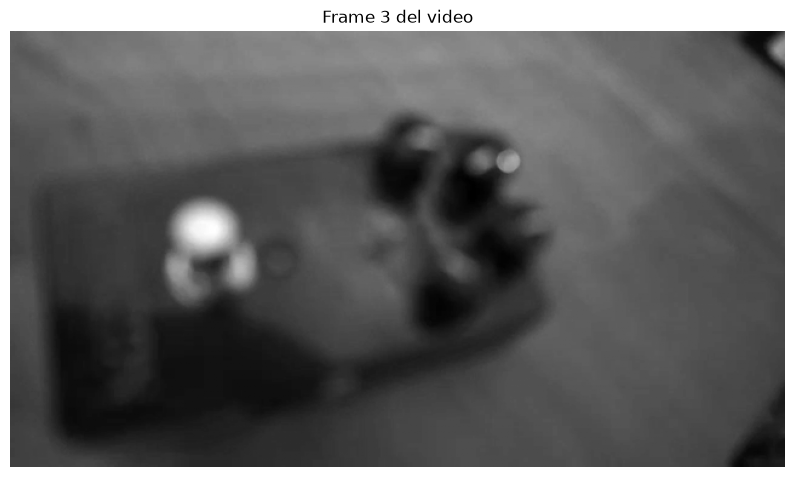

In [3]:
frames = leer_frames('focus_video.mov')
print(f"Cantidad total de frames leídos: {len(frames)}")

mostrar_imagen(frames[2], titulo="Frame 3 del video")

In [4]:
def roi_central(frame, escala=0.10):
    alto, ancho = frame.shape[:2]
    roi_alto = int(alto * np.sqrt(escala))
    roi_ancho = int(ancho * np.sqrt(escala))
    cy, cx = alto // 2, ancho // 2
    x1, x2 = cx - roi_ancho // 2, cx + roi_ancho // 2
    y1, y2 = cy - roi_alto // 2, cy + roi_alto // 2
    return x1, y1, x2, y2


def calcular_sharpness_fft(frames, roi=None, theta=1000):
    """
    Devuelve un array con la métrica de enfoque para cada frame
    y el índice del frame con máximo enfoque.
    """
    metricas = []
    for frame in frames:
        if roi:
            img = recortar(frame, roi)
        else:
            img = frame
        metricas.append(sharpness_fft(img, theta=theta))
    return np.array(metricas), int(np.argmax(metricas))


def recortar(frame, caja):
    x1, y1, x2, y2 = caja
    return frame[y1:y2, x1:x2]


def sharpness_fft(imagen, theta=1000):
    alto, ancho = imagen.shape[:2]

    f = np.fft.fft2(imagen)
    fc = np.fft.fftshift(f)
    af = np.abs(fc)

    max_val = np.max(af)
    thres = max_val / theta
    th = np.sum(af > thres)
    return th / (alto * ancho)

In [5]:
def unsharp_mask(imagen, sigma=5, amount=2.0):
    gauss = cv2.GaussianBlur(imagen, (0, 0), sigma)
    return cv2.addWeighted(imagen, amount, gauss, 1.0 - amount, 0)

In [6]:
def plot_curva_enfoque(metricas, idx_max, titulo='', figsize=(12, 4)):
    """Grafica la evolucion de la metrica marcando el frame de maximo enfoque."""
    plt.figure(figsize=figsize)
    plt.plot(metricas, label='Métrica FM')
    plt.axvline(x=idx_max, color='green', linestyle='--', alpha=0.7, label='Región de máximo enfoque')
    plt.scatter(idx_max, metricas[idx_max], color='red', s=100, zorder=5, label=f'Máximo: frame {idx_max} (FM={metricas[idx_max]:.4f})')
    plt.xlabel('Índice de frame')
    plt.ylabel('FM')
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Experimento frame completo

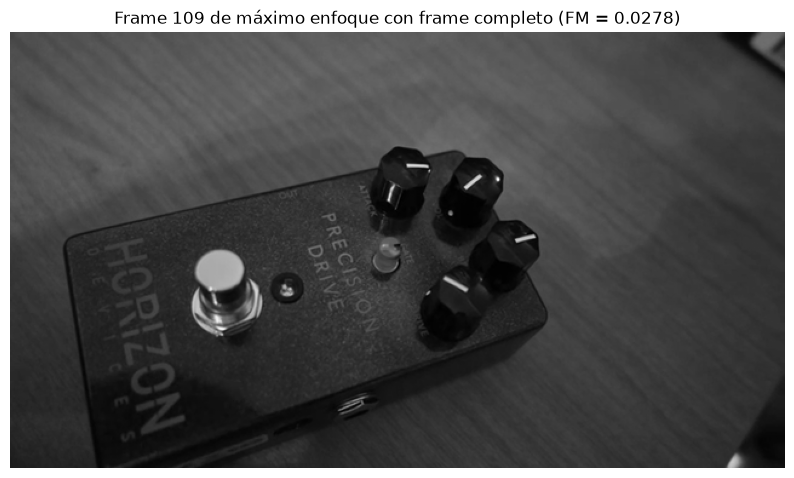

In [7]:
metricas_full, indice_max_full = calcular_sharpness_fft(frames, roi=None)
mostrar_imagen(frames[indice_max_full], titulo=f"Frame {indice_max_full} de máximo enfoque con frame completo (FM = {metricas_full[indice_max_full]:.4f})")

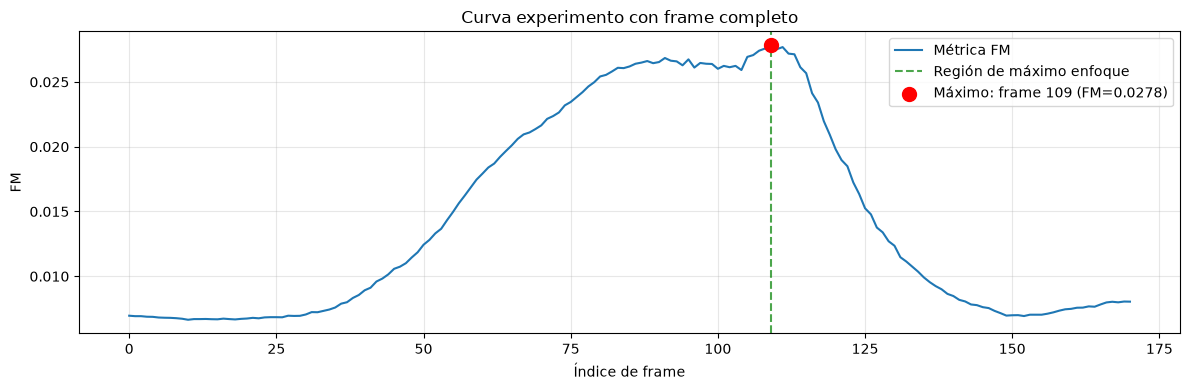

In [8]:
plot_curva_enfoque(metricas_full, indice_max_full, titulo="Curva experimento con frame completo")

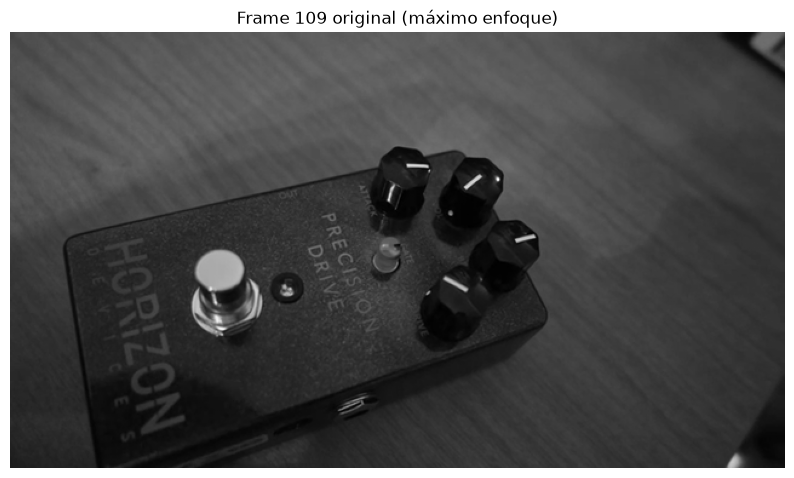

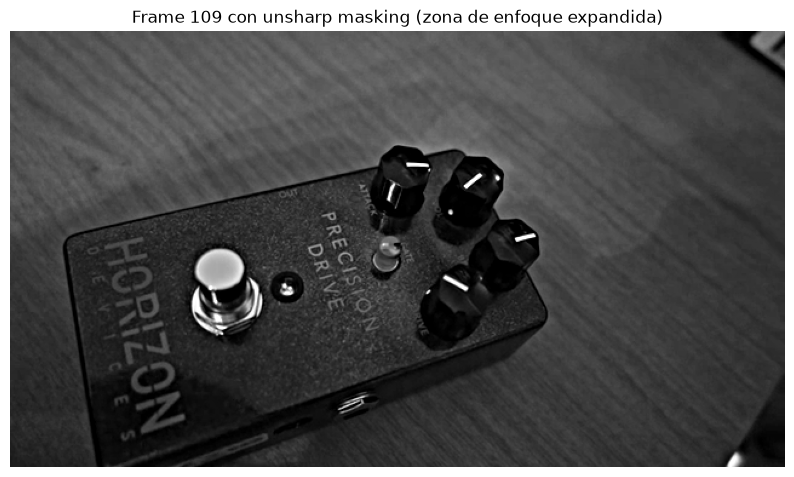

In [9]:
frame_nitido = frames[indice_max_full]
frame_realzado = unsharp_mask(frame_nitido, sigma=5, amount=2.0)

mostrar_imagen(frame_nitido, titulo=f"Frame {indice_max_full} original (máximo enfoque)")
mostrar_imagen(frame_realzado, titulo=f"Frame {indice_max_full} con unsharp masking (zona de enfoque expandida)")

In [10]:
# Verificamos cuantitativamente que la métrica de nitidez aumenta
print(f"FM original : {sharpness_fft(frame_nitido):.4f}")
print(f"FM realzado : {sharpness_fft(frame_realzado):.4f}")

FM original : 0.0278
FM realzado : 0.0602


## Experimento ROI central

In [11]:
# ESCALA_ROI = 0.05  # 5% del área total
ESCALA_ROI = 0.10  # 10% del área total
caja = roi_central(frames[0], ESCALA_ROI)
x1, y1, x2, y2 = caja
print(f"Tamaño del frame: {frames[0].shape[1]}x{frames[0].shape[0]}")
print(f"ROI: ({x1}, {y1}) -> ({x2}, {y2})  =  {x2-x1}x{y2-y1} px ({ESCALA_ROI*100:.0f}% del área)")

Tamaño del frame: 640x360
ROI: (219, 124) -> (421, 236)  =  202x112 px (10% del área)


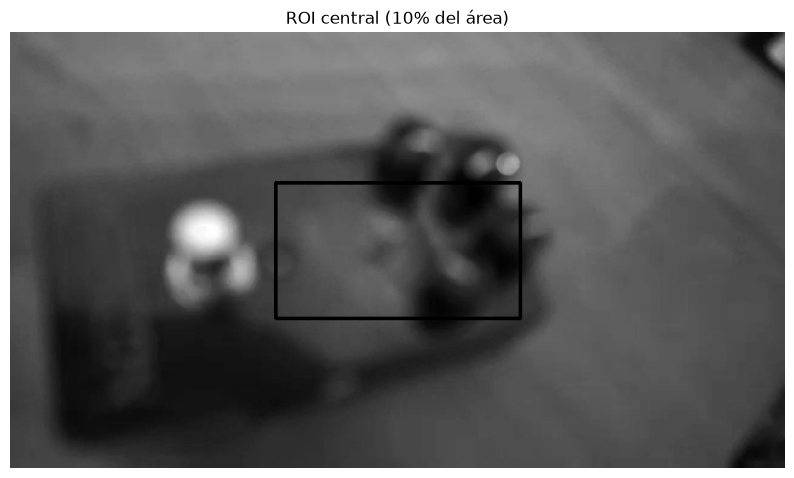

In [12]:
# Visualizar la ROI sobre un frame
frame_con_roi = frames[0].copy()
cv2.rectangle(frame_con_roi, (x1, y1), (x2, y2), (0, 255, 0), 2)
mostrar_imagen(frame_con_roi, titulo=f"ROI central ({ESCALA_ROI*100:.0f}% del área)")

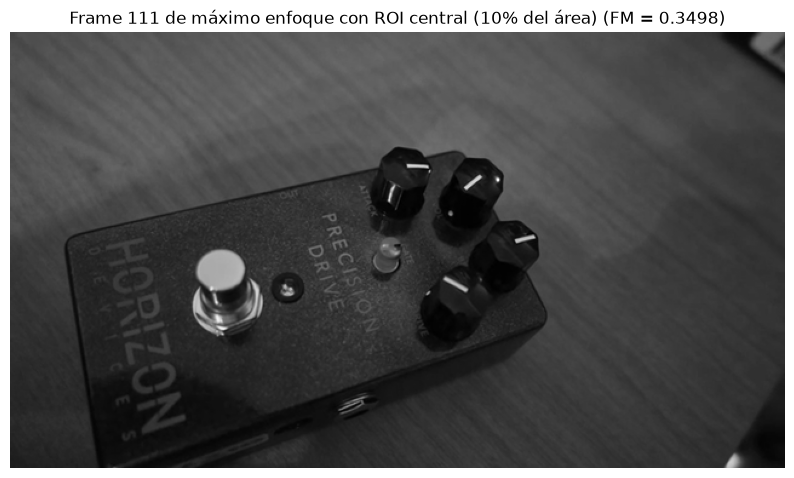

In [13]:
metricas_roi, indice_max_roi = calcular_sharpness_fft(frames, roi=caja)
mostrar_imagen(frames[indice_max_roi], titulo=f"Frame {indice_max_roi} de máximo enfoque con ROI central ({ESCALA_ROI*100:.0f}% del área) (FM = {metricas_roi[indice_max_roi]:.4f})")

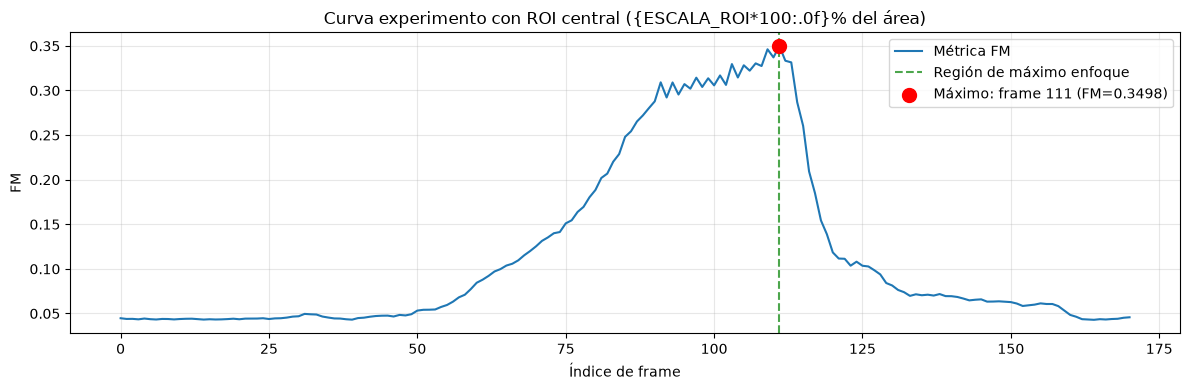

In [14]:
plot_curva_enfoque(metricas_roi, indice_max_roi, titulo="Curva experimento con ROI central ({ESCALA_ROI*100:.0f}% del área)")

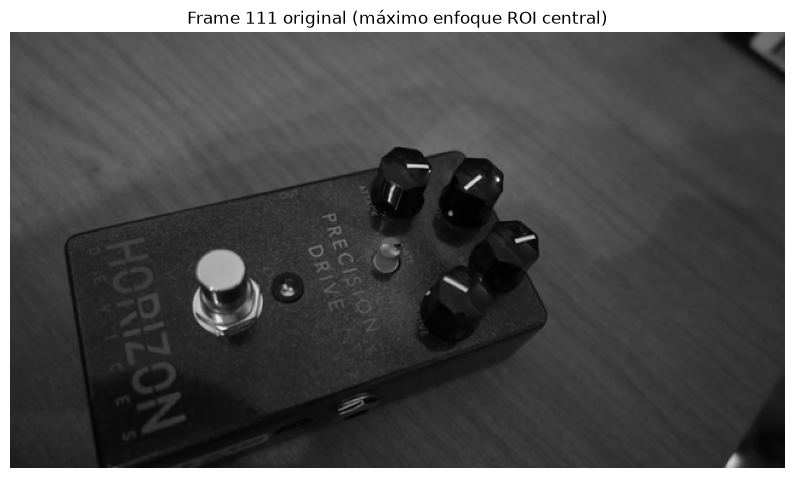

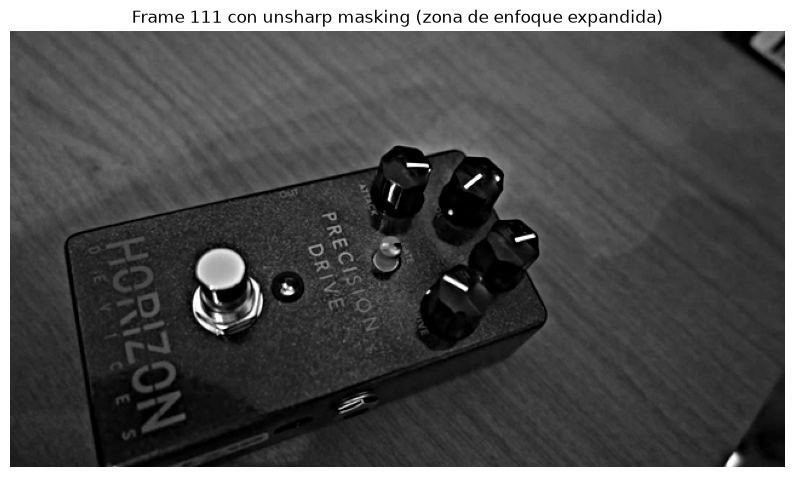

In [15]:
frame_nitido = frames[indice_max_roi]
frame_realzado = unsharp_mask(frame_nitido, sigma=5, amount=2.0)

mostrar_imagen(frame_nitido, titulo=f"Frame {indice_max_roi} original (máximo enfoque ROI central)")
mostrar_imagen(frame_realzado, titulo=f"Frame {indice_max_roi} con unsharp masking (zona de enfoque expandida)")

In [16]:
# Verificamos cuantitativamente que la métrica de nitidez aumenta
print(f"FM original : {sharpness_fft(frame_nitido):.4f}")
print(f"FM realzado : {sharpness_fft(frame_realzado):.4f}")

FM original : 0.0277
FM realzado : 0.0605


## Comparación de ambos experimentos

Superponemos las dos curvas (normalizadas a [0, 1] para comparar sus formas) y reportamos los
frames de máximo enfoque detectados automáticamente en cada caso.

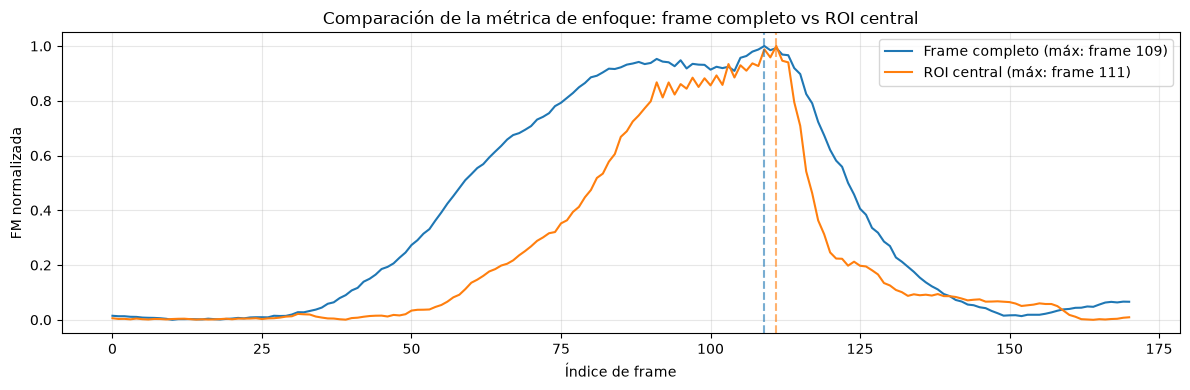

Frame de máximo enfoque (frame completo): 109
Frame de máximo enfoque (ROI central):   111


In [17]:
def _norm(x):
    x = np.asarray(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

plt.figure(figsize=(12, 4))
plt.plot(_norm(metricas_full), label=f'Frame completo (máx: frame {indice_max_full})')
plt.plot(_norm(metricas_roi), label=f'ROI central (máx: frame {indice_max_roi})')
plt.axvline(indice_max_full, color='C0', linestyle='--', alpha=0.6)
plt.axvline(indice_max_roi, color='C1', linestyle='--', alpha=0.6)
plt.xlabel('Índice de frame')
plt.ylabel('FM normalizada')
plt.title('Comparación de la métrica de enfoque: frame completo vs ROI central')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Frame de máximo enfoque (frame completo): {indice_max_full}")
print(f"Frame de máximo enfoque (ROI central):   {indice_max_roi}")